This notebook generates Fig. 9 of the manuscript and expects as input the data for the given mass, beta and N_sigma for both N_t=4,6. To plot this one must change the path to the files and have the libraries used in the plotting script installed.
The code to generate the data in the npz files one has to execute the eval_dense_pca.py files

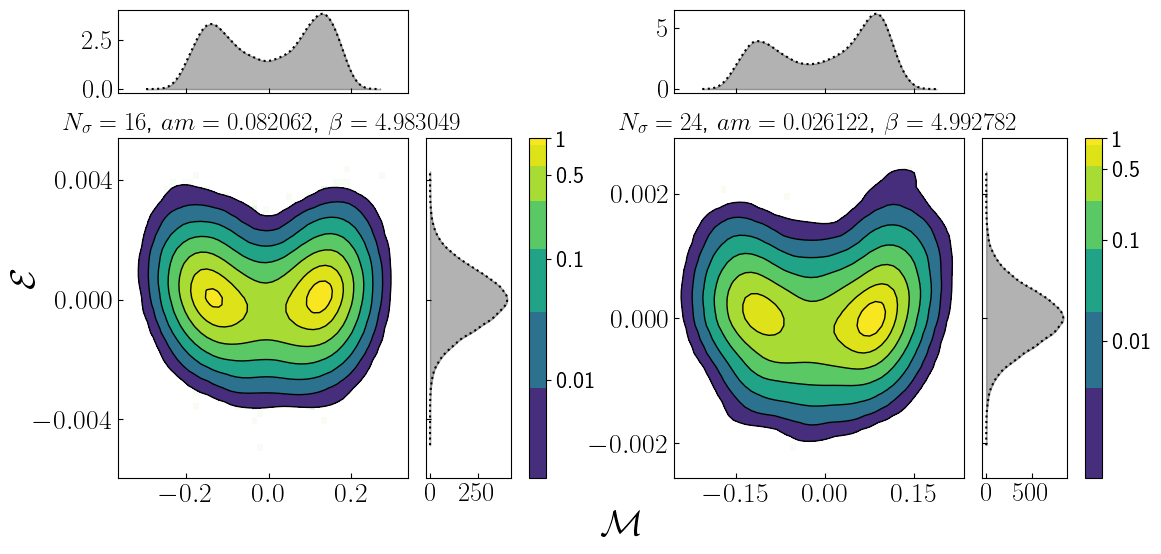

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde
from matplotlib.ticker import MaxNLocator

plt.rcParams["text.usetex"] = True

# -------------------- 1D KDE FOR MARGINALS --------------------
def plot_kde(ax, data, color="black", linestyle=":", vertical=False):
    kde = gaussian_kde(data)  # default bw
    x = np.linspace(np.min(data), np.max(data), 300)
    y = kde(x)
    if vertical:
        ax.plot(y, x, color=color, linestyle=linestyle)
        ax.fill_betweenx(x, 0, y, color=color, alpha=0.3)
    else:
        ax.plot(x, y, color=color, linestyle=linestyle)
        ax.fill_between(x, y, color=color, alpha=0.3)

# -------------------- LOAD NPZ -> DATAFRAME --------------------
def load_npz_to_df(path):
    npz = np.load(path, allow_pickle=True)
    result = npz["result"]  # (vol, mass, beta, chis, acts)

    rows = []
    for vol, mass, beta, chis, acts in result:
        chis = np.asarray(chis)
        acts = np.asarray(acts)
        n = len(chis)
        rows.append(pd.DataFrame({
            "N_sigma": np.full(n, float(vol)),
            "mass":    np.full(n, float(mass)),
            "beta":    np.full(n, float(beta)),
            "psi":     chis,
            "S":       acts,
        }))
    return pd.concat(rows, ignore_index=True)

def pick_one_block(df, N_sigma, mass=None, beta=None):
    """
    Filters to N_sigma (and optionally mass/beta). If multiple (mass,beta) remain,
    it picks the first one (minimal behavior).
    """
    sub = df[df["N_sigma"] == N_sigma].copy()
    if mass is not None:
        sub = sub[np.isclose(sub["mass"], mass, atol=1e-6)]
    if beta is not None:
        sub = sub[np.isclose(sub["beta"], beta, atol=1e-6)]

    if len(sub) == 0:
        raise ValueError(f"No rows found for N_sigma={N_sigma} (mass={mass}, beta={beta}).")

    keys = sub[["mass", "beta"]].drop_duplicates()
    m0 = float(keys.iloc[0]["mass"])
    b0 = float(keys.iloc[0]["beta"])

    sub = sub[np.isclose(sub["mass"], m0, atol=1e-6) & np.isclose(sub["beta"], b0, atol=1e-6)]
    return sub, m0, b0

def make_panel(fig, subspec, pc1, pc2, xlim, ylim, title, number_bins=50, bw2d=0.25):
    gs = GridSpecFromSubplotSpec(
        4, 5, subplot_spec=subspec,
        width_ratios=[1, 1, 1, 1, 0.20],
        wspace=0.25, hspace=0.55
    )

    ax_main = fig.add_subplot(gs[1:4, 0:3])
    ax_x    = fig.add_subplot(gs[0:1, 0:3], sharex=ax_main)
    ax_y    = fig.add_subplot(gs[1:4, 3:4], sharey=ax_main)
    ax_cbar = fig.add_subplot(gs[1:4, 4:5])

    # ML output: 2D hist
    ax_main.hist2d(
        pc1, pc2,
        density=True,
        bins=number_bins,
        cmap="Greens",
        norm=colors.LogNorm(),
        range=[list(xlim), list(ylim)]
    )

    # 2D KDE on grid
    xedges = np.linspace(xlim[0], xlim[1], number_bins)
    yedges = np.linspace(ylim[0], ylim[1], number_bins)
    X, Y = np.meshgrid(xedges, yedges)

    samples = np.vstack((pc1, pc2))
    kde = gaussian_kde(samples, bw_method=bw2d)
    positions = np.vstack([X.ravel(), Y.ravel()])
    Z = np.reshape(kde(positions).T, X.shape)

    # --- normalize KDE so the colorbar is in [0, 1] ---
    Zmax = float(Z.max())
    Z = Z / Zmax  # now max(Z)=1

    # Contour levels (keep your original construction, then normalize)
    vmax = 1.0
    hmin = 2.0
    C = np.sqrt(np.log((Zmax) / hmin))
    n_levels = 8
    levels = np.linspace(0, C, n_levels)
    levels = Zmax * np.exp(-levels**2)[::-1]
    levels_sorted = np.sort(levels / Zmax)  # normalized levels in (0,1]
    levels_sorted[-1] = 1.0

    contourf = ax_main.contourf(
        X, Y, Z,
        levels=levels_sorted,
        cmap="viridis",
        norm=colors.LogNorm(vmin=levels_sorted[0], vmax=1.0)
    )
    ax_main.contour(X, Y, Z, levels=levels_sorted, colors="black", linewidths=1)

    cbar = fig.colorbar(contourf, cax=ax_cbar)

    # Ticks/labels shown as normalized values in [0,1]
    tick_candidates = np.array([levels_sorted[0], 1e-2, 1e-1, 0.5, 1.0])
    ticks = tick_candidates[tick_candidates >= levels_sorted[0]]
    cbar.set_ticks(ticks[-4:])
    cbar.set_ticklabels([f"{t:g}" for t in ticks[-4:]])
    cbar.ax.tick_params(labelsize=17)
    # Marginals 
    plot_kde(ax_x, pc1, color="black", linestyle=":")
    plot_kde(ax_y, pc2, color="black", linestyle=":", vertical=True)

    ax_main.set_title(title, fontsize=18)
    ax_main.tick_params(axis="both", which="both", labelsize=20, direction="in")
    ax_main.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax_main.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax_x.tick_params(axis="both", which="both", labelsize=19, direction="in")
    ax_y.tick_params(axis="both", which="both", labelsize=19, direction="in")
    ax_x.tick_params(axis="x", labelbottom=False)
    ax_y.tick_params(axis="y", labelleft=False)

    return ax_main

# --------------------  --------------------
path_left  = "path/to/folder/Nt4/Nf5_ml0.08206.dat.npz" # <- change this 
path_right = "path/to/folder/Nt6/Nf5_ml0.02612.dat.npz" # <- change this

N_left  = 16
N_right = 24

number_bins = 50
padd = 0.12

# -------------------- LOAD + FILTER --------------------
dfL = load_npz_to_df(path_left)
dfR = load_npz_to_df(path_right)

blockL, mL, bL = pick_one_block(dfL, N_left,  mass=mass_left,  beta=beta_left)
blockR, mR, bR = pick_one_block(dfR, N_right, mass=mass_right, beta=beta_right)

# -------------------- PCA (separately, since N_sigma differs) --------------------
X0L = np.column_stack([blockL["psi"].to_numpy(), blockL["S"].to_numpy()])
X0R = np.column_stack([blockR["psi"].to_numpy(), blockR["S"].to_numpy()])

pcaL = PCA(n_components=2).fit(X0L)
pcaR = PCA(n_components=2).fit(X0R)

XL = pcaL.transform(X0L)
XR = pcaR.transform(X0R)

pc1L, pc2L = XL[:, 0], XL[:, 1]
pc1R, pc2R = XR[:, 0], XR[:, 1]

def padded_limits(x, y, padd=0.2):
    xr = float(np.max(x) - np.min(x))
    yr = float(np.max(y) - np.min(y))
    xlim = (float(np.min(x) - padd * xr), float(np.max(x) + padd * xr))
    ylim = (float(np.min(y) - padd * yr), float(np.max(y) + padd * yr))
    return xlim, ylim

xlimL, ylimL = padded_limits(pc1L, pc2L, padd=padd)
xlimR, ylimR = padded_limits(pc1R, pc2R, padd=padd)

# -------------------- main part for figure --------------------
fig = plt.figure(figsize=(12, 6))
outer = GridSpec(1, 2, figure=fig, wspace=0.3)

ax_main_L = make_panel(
    fig, outer[0, 0],
    pc1L, pc2L,
    xlimL, ylimL,
    title=rf"$N_\sigma={N_left}$, $am={mL:.6f}$, $\beta={bL:.6f}$",
    number_bins=number_bins
)

ax_main_R = make_panel(
    fig, outer[0, 1],
    pc1R, pc2R,
    xlimR, ylimR,
    title=rf"$N_\sigma={N_right}$, $am={mR:.6f}$, $\beta={bR:.6f}$",
    number_bins=number_bins
)

fig.supxlabel(r"$\mathcal{M}$", fontsize=26)
fig.supylabel(r"$\mathcal{E}$", fontsize=26, x=-0.01, y=0.45)

fig.subplots_adjust(left=0.08, bottom=0.12, top=0.90)
#plt.savefig("outlook_Nt64_v3.pdf",bbox_inches="tight", pad_inches=0.05)
plt.show()
